# Airline Equity Return Forecasting with Fama-French Factors and Cancellation Data
This project forecasts airline stock returns using historical stock prices, risk measures, and Fama-French factors. These variables are used to build a baseline model, which is then compared with a second model that includes airline cancellation rates to determine whether airline cancellation data improves forecasting performance.

Airlines: 
- American
- Delta
- United
- Southwest
- Alaska

Risk Measures: 
- 30-day annualized volatility: measures stock volatility over past 30 days
- 30 day downside volatility: only looks at negative returns over past 30 days
- 252-day rolling beta: measures how sensitive the stocks are to overall market over the past trading year

  
Fama-French Factors:
- Mkt-Rf: market return minus the risk free rate
- SMB: small-cap stock returns minus large-cap stock returns
- HML: high-value stock returns minus growth stock returns



## Part 1: Setup

#### Import necessary packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from pathlib import Path
import statsmodels.api as sm
import requests
import zipfile
import io

#### Download Airline Stock Data


In [2]:
# airlines we will be looking at, along with their tickers
airlines = {
    "AAL": "American Airlines",
    "DAL": "Delta Air Lines",
    "UAL": "United Airlines",
    "LUV": "Southwest Airlines",
    "ALK": "Alaska Air Group", }

benchmark = "SPY" # using the S&P 500 as a benchmark to compare airline returns

# start and end date for gathering stock history
start ="2015-01-01" 
end = "2026-01-02"

tickers = list(airlines) + [benchmark]
print("Tickers:",tickers)
print("Data from", start,"to",end)

Tickers: ['AAL', 'DAL', 'UAL', 'LUV', 'ALK', 'SPY']
Data from 2015-01-01 to 2026-01-02


In [3]:
#setting folders: data and figures


# creates folder data, and subfolder raw
# folder holds the raw data taken from Yahoo finance
raw_directory = Path("data/raw") 
raw_directory.mkdir(parents=True, exist_ok=True)

# creates subfolder "processed in folder data
# folder holds the cleaned up data
processed_directory = Path("data/processed") 
processed_directory.mkdir(parents=True, exist_ok=True)

# creates folder figures
# folder holds all graphs/images we make
figure_directory = Path("figures") 
figure_directory.mkdir(parents=True, exist_ok=True)


In [4]:
#downloading adjusted closing prices for the airlines into a pandas DataFrame
#source: Yahoo Finance

prices = yf.download(tickers,start=start,end=end, auto_adjust = True)["Close"] # taking closing prices throughout the date range

prices = prices.dropna() #removes any dates that dont have closing prices 
prices = prices[tickers] # re-orders headers so SPY appears last

display(prices.head())
    

[*********************100%***********************]  6 of 6 completed


Ticker,AAL,DAL,UAL,LUV,ALK,SPY
Date,,,,,,
2015-01-02,51.079903,42.729160,66.339996,37.374599,55.159008,169.687851
2015-01-05,51.051487,42.016727,66.150002,36.455334,54.372726,166.623337
2015-01-06,50.255596,41.026245,64.580002,35.422249,53.732723,165.053925
2015-01-07,50.227150,40.809040,65.529999,35.719929,54.555584,167.110718
2015-01-08,50.843025,41.869007,66.639999,36.665459,55.497303,170.076080


### Save Prices and Daily Returns

In [5]:
#calculate daily returns (percent)

returns = prices.pct_change() # new data frame for percent returns per day

# save prices
prices.to_csv("data/processed/daily_close.csv", index_label="date")

# save returns
returns.to_csv("data/processed/daily_returns.csv", index_label="date")


### Plot Performance

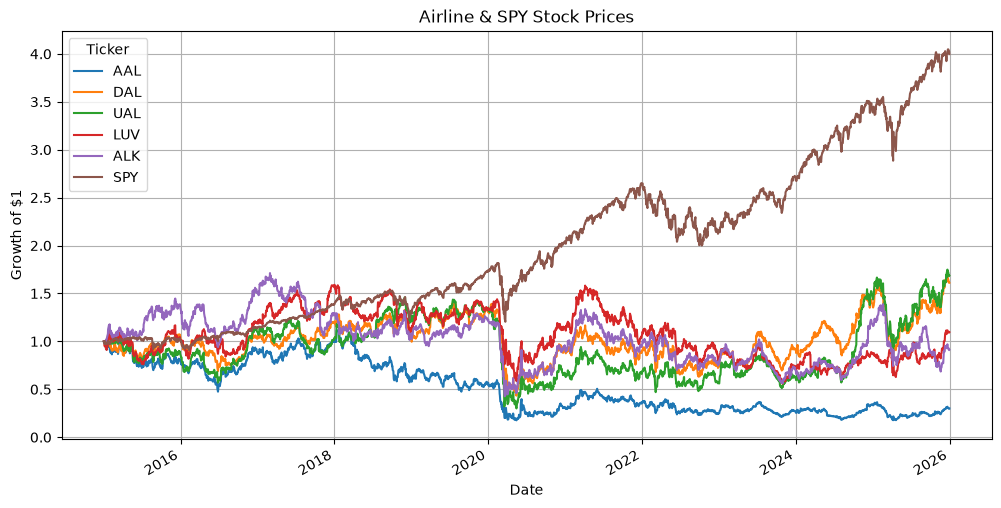

In [6]:
# growth of $1 invested into each stock on 1/1/2015
# use growth of $1 since all airline stock prices are at very different amounts, so hard to compare stock prices directly

growth_1 = prices / prices.iloc[0]
plot1 = growth_1.plot(figsize=(12,6))
plot1.set_title("Airline & SPY Stock Prices")
plot1.set_xlabel("Date")
plot1.set_ylabel("Growth of $1")
plot1.grid()

plt.savefig(figure_directory / "Growth of $1.png")






## Part 2: Risk Measures

##### Trailing 30-day annualized volatility
- first calculate stnd deviation of daily returns over the past 30 days
- then analyze it by multiplying by sqr root of 252

##### Trailing 30-day annualized downside volatility
- set all positive daily returns equal to zero so we only look at negative returns 
- square those returns and calculate their average over the past 30 days
- take the square root to get downside volatility
- Annualize it by multiplying by sqr root of 252

##### 252 day rolling beta
$$
\beta =
\frac{
\operatorname{Cov}(R_{\text{stock}}, R_{\text{market}})
}{
\operatorname{Var}(R_{\text{market}})
}
$$

In [7]:
trading_days = 252
lookback = 30

#seperate the returns into the airlines and SPY
airline_returns = returns[list(airlines)] 
market_returns = returns[benchmark]



# 30 day rolling volatility

daily_volatility = airline_returns.rolling(30).std() # takes std deviation of the last 30 rows
annual_volatility_30days = daily_volatility * np.sqrt(252)


#30 day downside volatility

negative_returns = airline_returns.clip(upper=0) #makes all positive values equal to zero
mean = (negative_returns **2).rolling(30).mean() # squares, then takes mean of last 30 rows
daily_downside_volatility = np.sqrt(mean)
annual_downside_volatility_30days = daily_downside_volatility * np.sqrt(252)


#252 day CAPM Beta

market_variance = market_returns.rolling(252).var() # takes variance of last 252 rows in SPY
rolling_beta_252days = pd.DataFrame(index=returns.index) # takes the date column from returns data frame

#now will add each airline's beta to the new rolling beta data frame 

for ticker in airlines:
    stock_returns = returns[ticker] 
    covariance = stock_returns.rolling(252).cov(market_returns) #finds cov between stock and SPY
    beta = covariance / market_variance
    rolling_beta_252days[ticker] = beta # adds it to data frame as new column

print("trailing 30 day annualized volatility")
display(annual_volatility_30days.tail())
print("trailing 30 day annualized downside volatility")
display(annual_downside_volatility_30days.tail())
print("trailing 252 day CAPM beta relative to SPY")
display(rolling_beta_252days.tail())


trailing 30 day annualized volatility


Ticker,AAL,DAL,UAL,LUV,ALK
Date,,,,,
2025-12-24,0.376294,0.354940,0.403894,0.347237,0.451945
2025-12-26,0.370625,0.334391,0.380923,0.333457,0.445472
2025-12-29,0.364030,0.338995,0.377266,0.331580,0.444547
2025-12-30,0.354063,0.327684,0.368861,0.329045,0.440615
2025-12-31,0.334642,0.290010,0.323887,0.309999,0.390955


trailing 30 day annualized downside volatility


Ticker,AAL,DAL,UAL,LUV,ALK
Date,,,,,
2025-12-24,0.215022,0.184528,0.237183,0.151040,0.262130
2025-12-26,0.219550,0.184583,0.237979,0.151046,0.262130
2025-12-29,0.210526,0.190369,0.233189,0.149201,0.260917
2025-12-30,0.198987,0.176174,0.224283,0.147948,0.257020
2025-12-31,0.174629,0.117249,0.162169,0.120628,0.185352


trailing 252 day CAPM beta relative to SPY


,AAL,DAL,UAL,LUV,ALK
Date,,,,,
2025-12-24,1.707707,1.769565,2.006498,1.311749,1.667972
2025-12-26,1.706246,1.769696,2.005303,1.310479,1.665978
2025-12-29,1.710969,1.771778,2.008436,1.310540,1.671840
2025-12-30,1.710205,1.771758,2.008226,1.310298,1.671703
2025-12-31,1.712921,1.768891,2.007173,1.310672,1.668420


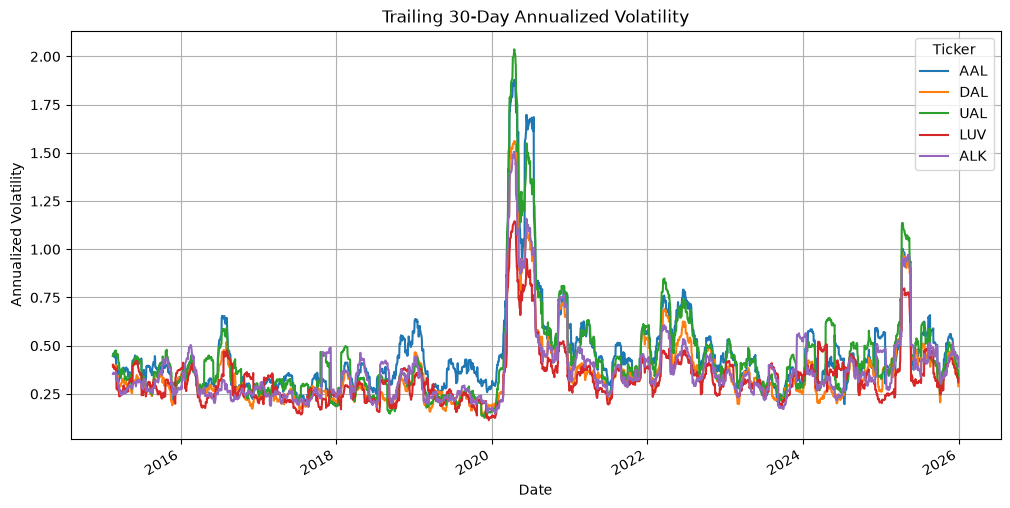

In [8]:
#plot 30 day annualized volatility

plot2 = annual_volatility_30days.plot(figsize=(12, 6))
plot2.set_title("Trailing 30-Day Annualized Volatility")
plot2.set_xlabel("Date")
plot2.set_ylabel("Annualized Volatility")
plot2.grid()
plt.savefig(figure_directory / "Trailing 30-Day Annualized Volatility.png")

plt.show()

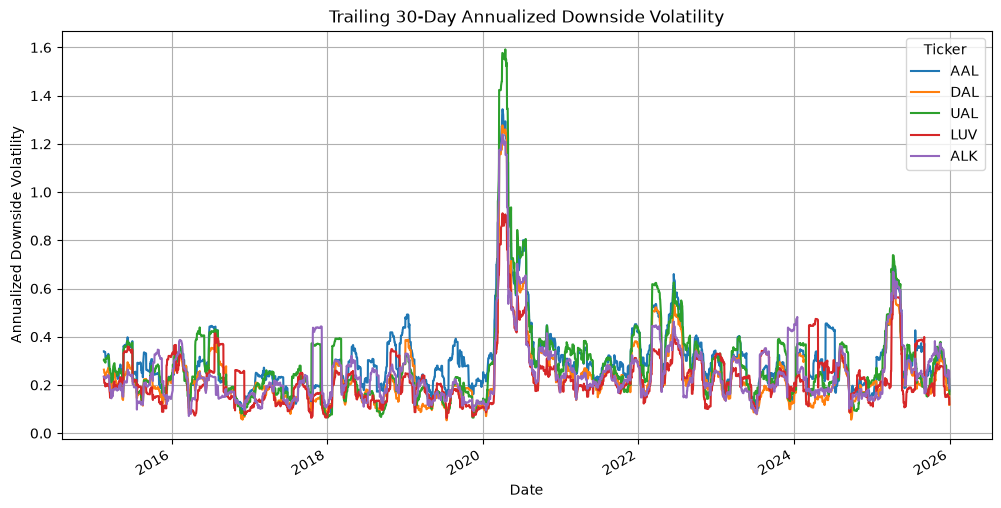

In [9]:
# Plot 30-day annualized downside volatility

plot3 = annual_downside_volatility_30days.plot(figsize=(12, 6))

plot3.set_title("Trailing 30-Day Annualized Downside Volatility")
plot3.set_xlabel("Date")
plot3.set_ylabel("Annualized Downside Volatility")
plot3.grid()
plt.savefig(figure_directory / "Trailing 30-Day Annualized Downside Volatility.png")


plt.show()

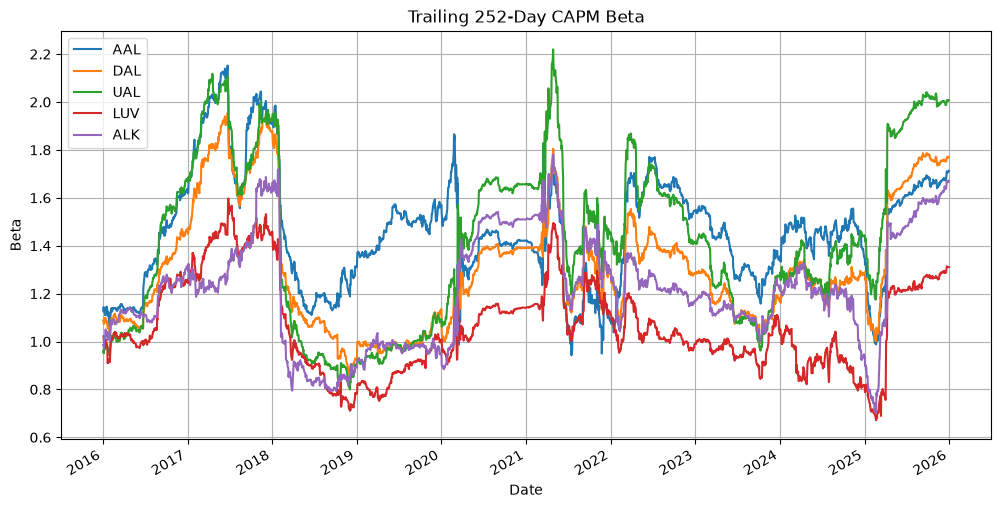

In [10]:
# Plot 252-day rolling CAPM beta

plot4 = rolling_beta_252days.plot(figsize=(12, 6))

plot4.set_title("Trailing 252-Day CAPM Beta")
plot4.set_xlabel("Date")
plot4.set_ylabel("Beta")
plot4.grid()
plt.savefig(figure_directory / "Trailing 252-Day CAPM Beta.png")

plt.show()



In [11]:
# Most recent volatility values

print("30-Day Annualized Volatility")
print(annual_volatility_30days.tail())

print()
print()

print("30-Day Annualized Downside Volatility")
print(annual_downside_volatility_30days.tail())

print()
print()

print("252-Day CAPM Beta")
print(rolling_beta_252days.tail())

30-Day Annualized Volatility
Ticker           AAL       DAL       UAL       LUV       ALK
Date                                                        
2025-12-24  0.376294  0.354940  0.403894  0.347237  0.451945
2025-12-26  0.370625  0.334391  0.380923  0.333457  0.445472
2025-12-29  0.364030  0.338995  0.377266  0.331580  0.444547
2025-12-30  0.354063  0.327684  0.368861  0.329045  0.440615
2025-12-31  0.334642  0.290010  0.323887  0.309999  0.390955


30-Day Annualized Downside Volatility
Ticker           AAL       DAL       UAL       LUV       ALK
Date                                                        
2025-12-24  0.215022  0.184528  0.237183  0.151040  0.262130
2025-12-26  0.219550  0.184583  0.237979  0.151046  0.262130
2025-12-29  0.210526  0.190369  0.233189  0.149201  0.260917
2025-12-30  0.198987  0.176174  0.224283  0.147948  0.257020
2025-12-31  0.174629  0.117249  0.162169  0.120628  0.185352


252-Day CAPM Beta
                 AAL       DAL       UAL       LUV       

In [12]:
# save risk calculations

annual_volatility_30days.to_csv("data/processed/volatility_30days.csv",index_label="date")

annual_downside_volatility_30days.to_csv("data/processed/downside_volatility_30days.csv",index_label="date")

rolling_beta_252days.to_csv("data/processed/beta_252days.csv",index_label="date")


# Part 2: Fama French 3 Factor Analysis
Fama French is used to explain a stock's return using three broad sources of return: market factor, size factor, and value factor. It's used to answer the question: "How much of the stock's return can be explained by overall market movement, company-size effects, and value vs growth effects?"

$$
R_{\text{airline}} - R_f
=
\alpha
+
\beta_M(\text{Mkt-RF})
+
\beta_S(\text{SMB})
+
\beta_H(\text{HML})
+
\epsilon
$$
- $R_{\text{airline}}$ = return of airline stock

- $R_f$ = risk free rate

- $\alpha$ = return not explained by the three Fama-French factors

- $\text{Mkt-RF}$ = market return minus the risk free rate, overall market movement

- $\text{SMB}$ = "Small Minus Big," the return difference between small-cap and large-cap stocks

- $\text{HML}$ = "High Minus Low," the return difference between high book-to-market value stocks and low book-to-market growth stocks

- $\epsilon$ = residual (airline stock's return not explained by the model)

In [13]:
# download daily Fama-French 3-factor data
# this contains daily observations for the Fama-French Factors

fama_french_url = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip")

fama_french = pd.read_csv(fama_french_url,compression="zip",skiprows= 3) # skip first 3 rows bc its just header text 

print(fama_french.head())

  Unnamed: 0  Mkt-RF   SMB   HML    RF
0   19260701    0.09 -0.25 -0.27  0.01
1   19260702    0.45 -0.33 -0.06  0.01
2   19260706    0.17  0.30 -0.39  0.01
3   19260707    0.09 -0.58  0.02  0.01
4   19260708    0.22 -0.38  0.19  0.01


#### Clean Fama French Data

In [14]:
# column 1 is unnamed and dates are in wrong format

# rename column 1
fama_french = fama_french.rename(columns={fama_french.columns[0]: "date"})



# Remove N/A rows
fama_french = fama_french.dropna()


#convert date column to correct format
fama_french["date"] = pd.to_datetime(fama_french["date"],format="%Y%m%d")

#make date the index (row label)
fama_french = fama_french.set_index("date")

#Convert data from percentages to decimals
fama_french = fama_french / 100



In [15]:
# now only look at the fama french dates that align with our stock data
# start ="2015-01-01" 
# end = "2026-01-02"

fama_french = fama_french.loc[prices.index.min():prices.index.max()]

print(fama_french.head())
print(fama_french.tail())

            Mkt-RF     SMB     HML   RF
date                                   
2015-01-02 -0.0012 -0.0059  0.0012  0.0
2015-01-05 -0.0184  0.0033 -0.0067  0.0
2015-01-06 -0.0103 -0.0079 -0.0029  0.0
2015-01-07  0.0119  0.0020 -0.0067  0.0
2015-01-08  0.0181 -0.0011 -0.0029  0.0
            Mkt-RF     SMB     HML      RF
date                                      
2025-12-24  0.0029  0.0004  0.0001  0.0002
2025-12-26 -0.0006 -0.0032  0.0009  0.0002
2025-12-29 -0.0041 -0.0016  0.0006  0.0002
2025-12-30 -0.0020 -0.0062  0.0031  0.0002
2025-12-31 -0.0076  0.0007 -0.0009  0.0002


#### Combine airline data with Fama French: Starting with American Airlines

In [16]:
# starting with American AAL

#create fama french dataset for american airlines
aal_fama = pd.DataFrame()

aal_fama["AAL return"] = returns["AAL"] # creates column AAL return in aal_fama with data taken from returns of AAL
aal_fama["Mkt-RF"] = fama_french["Mkt-RF"] 
aal_fama["SMB"] = fama_french["SMB"]
aal_fama["HML"] = fama_french["HML"]
aal_fama["RF"] = fama_french["RF"]


# airline return minus the risk-free return ( Ri - Rf )

aal_fama["excess return"] = (aal_fama["AAL return"] - aal_fama["RF"])

aal_fama = aal_fama.dropna()

print(aal_fama.head())

            AAL return  Mkt-RF     SMB     HML   RF  excess return
Date                                                              
2015-01-05   -0.000556 -0.0184  0.0033 -0.0067  0.0      -0.000556
2015-01-06   -0.015590 -0.0103 -0.0079 -0.0029  0.0      -0.015590
2015-01-07   -0.000566  0.0119  0.0020 -0.0067  0.0      -0.000566
2015-01-08    0.012262  0.0181 -0.0011 -0.0029  0.0       0.012262
2015-01-09   -0.030562 -0.0085  0.0000 -0.0047  0.0      -0.030562


#### Regression: American Airlines
Starting with one airline to see how it works, then will run through all other airlines using a for loop

In [17]:
# dependent variable
y = aal_fama["excess return"]

# explanatory variables
X = aal_fama[["Mkt-RF", "SMB", "HML"]]
X = sm.add_constant(X) # constant

# regressing excess return against the Fama French 3 factors and a constant

print(X.head())
print()
print(y.head())

            const  Mkt-RF     SMB     HML
Date                                     
2015-01-05    1.0 -0.0184  0.0033 -0.0067
2015-01-06    1.0 -0.0103 -0.0079 -0.0029
2015-01-07    1.0  0.0119  0.0020 -0.0067
2015-01-08    1.0  0.0181 -0.0011 -0.0029
2015-01-09    1.0 -0.0085  0.0000 -0.0047

Date
2015-01-05   -0.000556
2015-01-06   -0.015590
2015-01-07   -0.000566
2015-01-08    0.012262
2015-01-09   -0.030562
Name: excess return, dtype: float64


In [18]:
#run regression

aal_model = sm.OLS(y,X).fit()
print(aal_model.summary())

                            OLS Regression Results                            
Dep. Variable:          excess return   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     463.5
Date:                Sun, 30 Aug 2026   Prob (F-statistic):          7.30e-244
Time:                        14:20:27   Log-Likelihood:                 6135.4
No. Observations:                2765   AIC:                        -1.226e+04
Df Residuals:                    2761   BIC:                        -1.224e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0006      0.001     -1.120      0.2

Constant is Alpha  
Mkt-RF is airline's market factor exposure  
SMB tell us if airline behaves more like smaller or larger companies (positive value: more small cap exposure)  
HML tells us if airline behaves more like value or growth stock (positive value: more value exposure)  

#### Regression: All other Airlines

In [19]:
# Empty table for regression results

fama_french_results = pd.DataFrame() # data frame to hold all results 


for ticker in airlines: # loop through all airlines and add regression to data table

    # Create temporary dataset
    regression_data = pd.DataFrame()

    regression_data["stock return"] = returns[ticker]

    regression_data["Mkt-RF"] = fama_french["Mkt-RF"]
    regression_data["SMB"] = fama_french["SMB"]
    regression_data["HML"] = fama_french["HML"]
    regression_data["RF"] = fama_french["RF"]

    regression_data = regression_data.dropna()

    # stock return minus the risk-free rate
    regression_data["excess return"] = (regression_data["stock return"]- regression_data["RF"])

    # dependent variable
    y = regression_data["excess return"]

    # explanatory variables
    X = regression_data[["Mkt-RF", "SMB", "HML"]]

    # constant
    X = sm.add_constant(X)

    # regression
    regression = sm.OLS(y, X).fit()

    # save results to results data frame 
    fama_french_results.loc[ticker, "alpha"] = regression.params["const"]
    fama_french_results.loc[ticker, "market beta"] = regression.params["Mkt-RF"]
    fama_french_results.loc[ticker, "SMB beta"] = regression.params["SMB"]
    fama_french_results.loc[ticker, "HML beta"] = regression.params["HML"]
    fama_french_results.loc[ticker, "R squared"] = regression.rsquared



In [20]:
# convert alpha to annual
fama_french_results["annual alpha"] = (fama_french_results["alpha"] * 252)
print(fama_french_results)

        alpha  market beta  SMB beta  HML beta  R squared  annual alpha
AAL -0.000561     1.373406  0.773171  0.835523   0.334920     -0.141485
DAL -0.000109     1.274278  0.566232  0.705161   0.420992     -0.027511
UAL  0.000041     1.413180  0.847327  0.934662   0.387571      0.010253
LUV -0.000216     1.032777  0.477782  0.588328   0.358434     -0.054550
ALK -0.000282     1.239041  0.637724  0.732082   0.406594     -0.071039


In [21]:
# save results

fama_french_results.to_csv("data/processed/fama_french_results.csv",index_label="ticker")

#### Interpretation of Fama French Regression Results

All of the five airline stocks have betas above 1, meaning they are sensitive to broad market movements. UAL has the highest market beta at 1.41, followed by AAL at 1.37, while LUV has the lowest at 1.03.

All airlines have positive SMB and HML betas, showing that they are all affected by both the small-cap and value-stock factors. This means their returns tend to move in the same direction as these factors, so they generally perform better when small-cap stocks outperform large-cap stocks and when value stocks outperform growth stocks. UAL has the strongest affect, with an SMB beta of 0.85 and an HML beta of 0.93.

The R squared values range from approximately 0.33 to 0.42, meaning the three Fama-French factors explain about 33% to 42% of the variation in daily airline returns. DAL has the highest R-squared at 0.42, suggesting that its returns are the best explained by these factors among the five airlines. However, these values are still low, meaning that more than half of the variation in each airline’s daily returns is left unexplained by the model. This means that other factors may also be important to correctly model the stock.

Most airlines produced negative alpha, while UAL had a small positive alpha of approximately 1.03%. Overall, the results show that airline stocks are strongly exposed to market movements, but a large portion of their daily return variation is not explained by the Fama French three factor model.

# Part 3: Forward 30-day Return Target

This measures how much an airline stock’s price changes over the next 30 trading days. It is calculated by comparing the stock price 30 trading days in the future with its current price. This variable is what we will try to predict in the upcoming forecasting model using variables like volatility, beta, Fama-French factors, and airline cancellation rates.

In [22]:
#calculate forward 30-day returns

forward_return_30d= (prices[list(airlines)].shift(-30) / prices[list(airlines)] -1)
forward_return_30d.index.name = "date"

# takes price 30 days in the future, divides by today's price, and subtracts 1 to get the percent change in stock price over 30 days

In [23]:
# save results

forward_return_30d.to_csv("data/processed/forward_return_30days.csv",index_label="date")

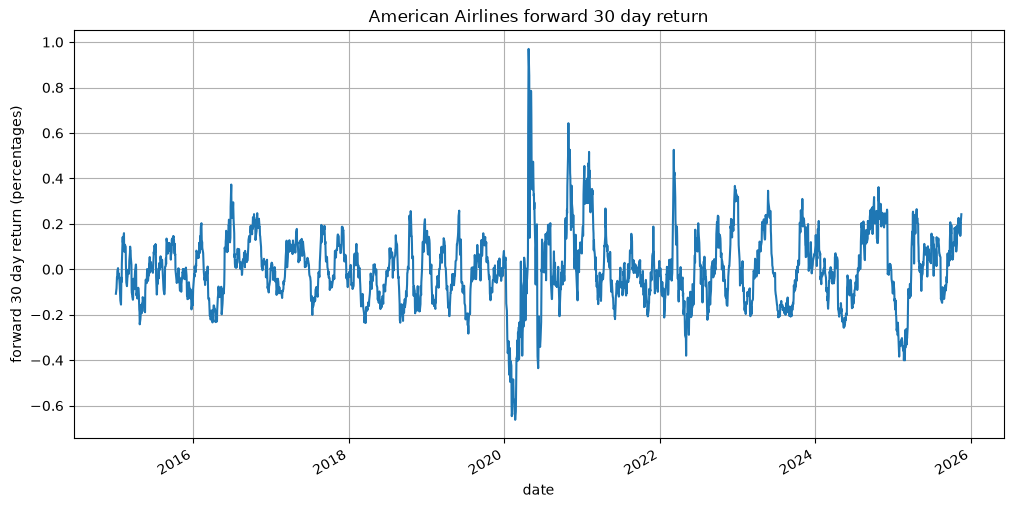

In [24]:
# plotting one airline (American) to see results
# 30 day returns for AAL

plot5 = forward_return_30d["AAL"].plot(figsize=(12,6))
plot5.set_title("American Airlines forward 30 day return")
plot5.set_xlabel("date")
plot5.set_ylabel("forward 30 day return (percentages)")
plot5.grid()


# Part 4: Airline Cancellation Data (Optional)
This data has already been downloaded and saved as a CSV file. This section only needs to be run if you want to reproduce the cancellation-rate dataset from the original BTS data.

#### Downloading Cancellation Data from Bureau of Transportation Stats (BTS)

In [ ]:
cancellation_data_directory = Path("data/raw/cancellation_data") # sets up folder to hold the data
cancellation_data_directory.mkdir(parents=True, exist_ok=True)

In [ ]:

from concurrent.futures import ThreadPoolExecutor, as_completed


# Match BTS airline codes to stock tickers
carrier_to_ticker = {
    "AA": "AAL",
    "DL": "DAL",
    "UA": "UAL",
    "WN": "LUV",
    "AS": "ALK"}


# Convert project dates to datetime
start_date = pd.to_datetime(start)
end_date = pd.to_datetime(end)


# Create one date for every month in the project period
months = pd.date_range( start=start_date, end=end_date,freq="MS")

In [ ]:

# Match BTS airline codes to stock tickers
carrier_to_ticker = {
    "AA": "AAL",
    "DL": "DAL",
    "UA": "UAL",
    "WN": "LUV",
    "AS": "ALK"}

# using a later start date for cancellation modelling to limit how much data we need to download
start_cancellations = "2019-01-01"


# Convert project dates to datetime
start_date = pd.to_datetime(start_cancellations)
end_date = pd.to_datetime(end)


# Create one date for every month
months = pd.date_range( start=start_date, end=end_date, freq="MS")


# Empty list to store monthly results
monthly_cancellation_rates = []

In [ ]:
for date in months:

    year = date.year
    month = date.month

    file_name = (
        "On_Time_Reporting_Carrier_On_Time_Performance_1987_present_" + str(year) + "_" + str(month) + ".zip" )

    url = ( "https://transtats.bts.gov/PREZIP/"+ file_name)

    print("downloading:", year, month)

    # Try downloading up to 3 times
    for attempt in range(3):

        try:
            response = requests.get(url, timeout=120)
            break

        except requests.exceptions.RequestException:

            print("retrying:", year, month)

    # Open ZIP
    zip_file = zipfile.ZipFile(
        io.BytesIO(response.content)
    )

    csv_name = [
        name for name in zip_file.namelist()
        if name.lower().endswith(".csv")
    ][0]

    monthly_data = pd.read_csv(
        zip_file.open(csv_name),
        usecols=[
            "Reporting_Airline",
            "Cancelled" ] )

    monthly_data = monthly_data[
        monthly_data["Reporting_Airline"].isin(
            carrier_to_ticker)]

    monthly_data["ticker"] = (
        monthly_data["Reporting_Airline"]
        .map(carrier_to_ticker))

    monthly_rates = (
        monthly_data
        .groupby("ticker")["Cancelled"]
        .mean()
        .reset_index())

    monthly_rates["date"] = date

    monthly_cancellation_rates.append(
        monthly_rates)

In [ ]:
cancellation_rates = pd.concat( monthly_cancellation_rates, ignore_index=True )

In [ ]:
cancellation_rates = cancellation_rates.sort_values( ["date", "ticker"])

In [ ]:
cancellation_rates = cancellation_rates.rename(
    columns={
        "Cancelled": "cancellation_rate"})

In [ ]:
print(cancellation_rates.head(10))
print(cancellation_rates.tail(10))

In [ ]:
cancellation_rates.to_csv("data/processed/monthly_cancellation_rates.csv",index=False)

# Part 5: Building and Forecasting the Model
Now we will build the forecasting models used to predict each airline’s forward 30-day return. The baseline model uses risk measures and Fama-French factors as predictor variables. The second model then adds airline cancellation rates as an additional predictor. The models are fit using ordinary least squares regression, and their predictions are evaluated using MAE, RMSE, and directional accuracy.

In [25]:
# take cancellation rates from part 4
cancellations = pd.read_csv("data/processed/monthly_cancellation_rates.csv")

# convert date column to datetime
cancellations["date"] = pd.to_datetime(cancellations["date"])

print(cancellations.head())

  ticker  cancellation_rate       date
0    AAL           0.019619 2019-01-01
1    ALK           0.020681 2019-01-01
2    DAL           0.004442 2019-01-01
3    LUV           0.035477 2019-01-01
4    UAL           0.014857 2019-01-01


In [26]:
print(cancellations.head())

  ticker  cancellation_rate       date
0    AAL           0.019619 2019-01-01
1    ALK           0.020681 2019-01-01
2    DAL           0.004442 2019-01-01
3    LUV           0.035477 2019-01-01
4    UAL           0.014857 2019-01-01


### We will first build the model just for American Airlines, then later loop through all airlines and model each one. We are starting with the model that includes cancellation rates, and then make another model as the baseline that excludes cancellation rates.

In [27]:
# isolate American Airlines cancellation data
aal_cancellations = cancellations[
    cancellations["ticker"] == "AAL"
].copy()

# set date as index
aal_cancellations = aal_cancellations.set_index("date")

# only keep cancellation rate
aal_cancellations = aal_cancellations[
    ["cancellation_rate"]
]


#### Since we are using cancellation rates to predict future returns, we use the previous month’s completed cancellation rate instead of the current month’s incomplete data, so the cancellation data is shifted back by one month

In [28]:
aal_cancellations["cancellation_rate"] = (aal_cancellations["cancellation_rate"].shift(1))
print(aal_cancellations.head())

            cancellation_rate
date                         
2019-01-01                NaN
2019-02-01           0.019619
2019-03-01           0.012103
2019-04-01           0.021480
2019-05-01           0.034313


#### now we have the correct monthly cancellation data, but our stock price data is daily

In [29]:
# combine the monthly cancellation dates with the daily stock return dates
combined_dates = aal_cancellations.index.union(returns.index)

# reindex using all of those dates
aal_cancellations = aal_cancellations.reindex(combined_dates)

# fill each monthly cancellation rate forward through the daily dates
aal_cancellations["cancellation_rate"] = (
    aal_cancellations["cancellation_rate"].ffill()
)

# keep only the trading dates used in the returns data
aal_cancellations = aal_cancellations.loc[returns.index]

# remove any remaining NaN rows
aal_cancellations = aal_cancellations.dropna()

print(aal_cancellations.head())

            cancellation_rate
Date                         
2019-02-01           0.019619
2019-02-04           0.019619
2019-02-05           0.019619
2019-02-06           0.019619
2019-02-07           0.019619


In [30]:
# create the data frame used for the models using the same index as returns
aal_model = pd.DataFrame(index=returns.index)


# add cancellation data
aal_model["cancellation_rate"] = aal_cancellations["cancellation_rate"]


In [31]:
# now add the variables we gathered from the prior parts to the data frame

# 30 day return
aal_model["forward_return_30d"]=forward_return_30d["AAL"]


#30 day volatility
aal_model["volatility_30d"] = annual_volatility_30days["AAL"]


# 30 day downside volatility
aal_model["downside_volatility_30d"] = annual_downside_volatility_30days["AAL"]


# 252 day beta
aal_model["beta_252d"] = rolling_beta_252days["AAL"]

# fama french factors
aal_model["Mkt-RF"] = fama_french["Mkt-RF"]
aal_model["SMB"] = fama_french["SMB"]
aal_model["HML"] = fama_french["HML"]

#remove NaN rows
aal_model = aal_model.dropna()


print(aal_model.head())

            cancellation_rate  forward_return_30d  volatility_30d  \
Date                                                                
2019-02-01           0.019619           -0.128620        0.565049   
2019-02-04           0.019619           -0.138768        0.555902   
2019-02-05           0.019619           -0.161657        0.552286   
2019-02-06           0.019619           -0.144450        0.539894   
2019-02-07           0.019619           -0.154824        0.530299   

            downside_volatility_30d  beta_252d  Mkt-RF     SMB     HML  
Date                                                                    
2019-02-01                 0.345201   1.353642  0.0013 -0.0012  0.0043  
2019-02-04                 0.331356   1.355762  0.0073  0.0048 -0.0047  
2019-02-05                 0.327951   1.354351  0.0043 -0.0007 -0.0061  
2019-02-06                 0.312335   1.375873 -0.0021 -0.0001  0.0006  
2019-02-07                 0.299591   1.374681 -0.0093 -0.0013  0.0038  


#### Now set up regression

In [32]:
# x variables are as follows

x = aal_model[[
        "volatility_30d",
        "downside_volatility_30d",
        "beta_252d",
        "Mkt-RF",
        "SMB",
        "HML",
        "cancellation_rate"]]


In [33]:
# Y variable: returns over the next 30 trading days

y = aal_model["forward_return_30d"]

In [34]:
# split data into training data and testing data

split = "2024-01-01"

x_train = x[x.index < split]
y_train = y[y.index < split]

x_test = x[x.index >=split]
y_test = y[y.index >= split]

In [35]:
# add constant

x_train = sm.add_constant(x_train)
x_test = sm.add_constant(x_test)

In [36]:
print(x_train.head())

            const  volatility_30d  downside_volatility_30d  beta_252d  Mkt-RF  \
Date                                                                            
2019-02-01    1.0        0.565049                 0.345201   1.353642  0.0013   
2019-02-04    1.0        0.555902                 0.331356   1.355762  0.0073   
2019-02-05    1.0        0.552286                 0.327951   1.354351  0.0043   
2019-02-06    1.0        0.539894                 0.312335   1.375873 -0.0021   
2019-02-07    1.0        0.530299                 0.299591   1.374681 -0.0093   

               SMB     HML  cancellation_rate  
Date                                           
2019-02-01 -0.0012  0.0043           0.019619  
2019-02-04  0.0048 -0.0047           0.019619  
2019-02-05 -0.0007 -0.0061           0.019619  
2019-02-06 -0.0001  0.0006           0.019619  
2019-02-07 -0.0013  0.0038           0.019619  


In [37]:
# run OLS on y_train and x_train
forecast = sm.OLS(y_train, x_train).fit()

print(forecast.summary())

                            OLS Regression Results                            
Dep. Variable:     forward_return_30d   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     17.34
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           5.25e-22
Time:                        14:20:35   Log-Likelihood:                 378.23
No. Observations:                1237   AIC:                            -740.5
Df Residuals:                    1229   BIC:                            -699.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

#### This OLS summary is for the model that includes cancellation data

$$
R_{t,t+30}
=
\alpha
+
\beta_1 \text{Volatility}
+
\beta_2 \text{Downside Volatility}
+
\beta_3 \text{Beta}
+
\beta_4 \text{MKT}
+
\beta_5 \text{SMB}
+
\beta_6 \text{HML}
+
\beta_7 \text{Cancellations}
+
\epsilon
$$

The OLS model has an R-squared of 0.090, meaning the predictors explain about 9.0% of the variation in AAL’s forward 30-day returns. Several of the individual predictors are statistically significant at the 5% level. The cancellation rate has a negative coefficient and is not statistically significant, meaning there is not enough evidence to conclude that cancellation rates have a reliable relationship with AAL’s forward 30-day returns. The model’s overall F-statistic p-value is approximately 5.25e-22, meaning the regression as a whole is statistically significant. Therefore, while the model contains predictors that are significantly related to future returns, cancellation rates themselves do not show a statistically significant relationship with future returns.

#### Now using the regression model, we will see if it actually predicts future returns using the testing data

In [38]:
predicted_returns = forecast.predict(x_test) 
# returns model predicts for test data
# actual returns are y_test

In [39]:
# results

forecast_results = pd.DataFrame(index =y_test.index)

forecast_results["actual_return"] = y_test
forecast_results["predicted_return"]= predicted_returns

#### Calculate mean squared error (MSE) and mean absolute error (MAE)

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

In [40]:
errors = forecast_results["actual_return"] - forecast_results["predicted_return"]

squared_errors = errors ** 2

mse = squared_errors.mean()
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 0.032264866087975914
RMSE: 0.17962423580345696


$$
MAE = \frac{1}{n}\sum_{i=1}^{n}\left|y_i - \hat{y}_i\right|
$$

In [41]:
absoblute_errors = abs(errors)

mae = absoblute_errors.mean()

print("MAE:", mae)

MAE: 0.14809208464053072


In [42]:
print("A Mean Absolute Error (MAE) value of",round(mae,4),
      "means that the prediction is off by about", 
      round(mae*100, 2),"percentage points on average")

print("")

print("A Root Mean Squared Error (RMSE) value of",round(rmse,4),
      "means that the prediction error is about", 
      round(rmse*100, 2),"percentage points")



A Mean Absolute Error (MAE) value of 0.1481 means that the prediction is off by about 14.81 percentage points on average

A Root Mean Squared Error (RMSE) value of 0.1796 means that the prediction error is about 17.96 percentage points


#### This shows that airline cancellations aren’t very good at predicting the size of future 30-day returns, but we can still see how well the model predicts whether the stock price will go up or down

In [43]:
# true or false depending on if there is positive returns
actual_direction = forecast_results["actual_return"]>0 
predicted_direction =forecast_results["predicted_return"] >0


accuracy = ( actual_direction == predicted_direction).mean()


print("The model accurately predicts whether the stock price will go up or down",round(accuracy*100,2),"percent of the time")

The model accurately predicts whether the stock price will go up or down 31.57 percent of the time


### Plot actual vs predicted returns

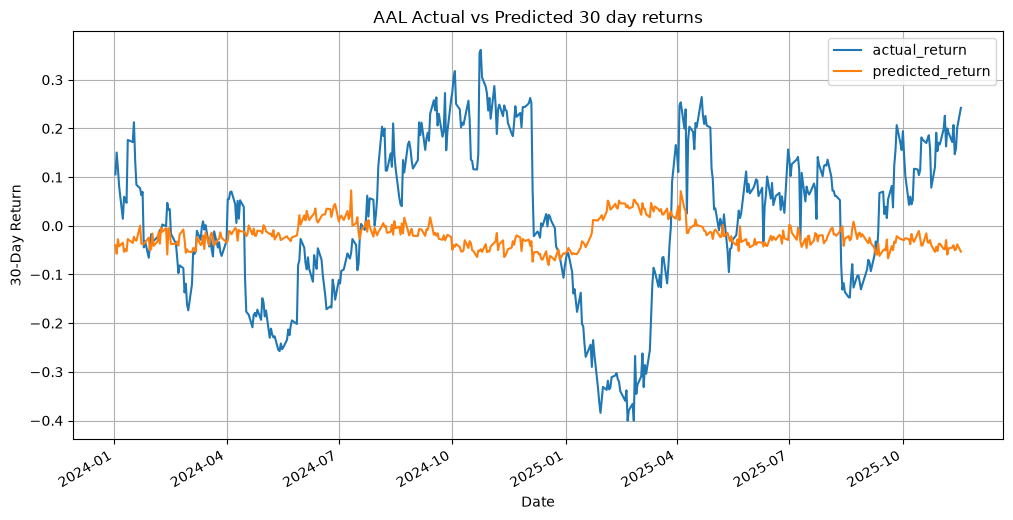

In [44]:
plot7 = forecast_results[["actual_return","predicted_return"]].plot(figsize=(12,6))

plot7.set_title("AAL Actual vs Predicted 30 day returns")
plot7.set_xlabel("Date")
plot7.set_ylabel("30-Day Return")
plot7.grid()

plt.savefig(figure_directory / "aal_actual_vs_predicted_returns.png",bbox_inches="tight")
plt.show()

# Part 6: Test whether cancellations actually help predict future returns
 Redo the model in part 5, but this time exclude airline cancellation data to get a baseline model

In [45]:
#exclude airline cancellations

x_baseline = aal_model[[
        "volatility_30d",
        "downside_volatility_30d",
        "beta_252d",
        "Mkt-RF",
        "SMB",
        "HML",]]

In [46]:
# split data into test and train data
split = "2024-01-01"

x_baseline_train = x_baseline[x_baseline.index < split]
x_baseline_test = x_baseline[x_baseline.index >=split]

#add constants
x_baseline_train = sm.add_constant(x_baseline_train)
x_baseline_test = sm.add_constant(x_baseline_test)


In [47]:
# run baseline model:
baseline_model = sm.OLS(y_train, x_baseline_train).fit()

#predict future returns
baseline_predictions = baseline_model.predict(x_baseline_test)

#### Calculate MAE, MSE, RMSE for the baseline and compare to the original results to see if adding airline cancellation data improves the model

In [48]:
# baseline prediction errors
baseline_errors = y_test - baseline_predictions

# square errors
baseline_squared_errors = baseline_errors ** 2

# Mean Squared Error (MSE)
baseline_mse = baseline_squared_errors.mean()

# Root Mean Squared Error (RMSE)
baseline_rmse = np.sqrt(baseline_mse)

# Mean Absolute Error (MAE)
baseline_absolute_errors = abs(baseline_errors)
baseline_mae = baseline_absolute_errors.mean()

print("Baseline MSE:", baseline_mse)
print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline MSE: 0.03313274655202279
Baseline RMSE: 0.18202402740304038
Baseline MAE: 0.14984237003808973


#### Compare findings

In [49]:
print("Baseline MAE:", baseline_mae)
print("Cancellation Model MAE:", mae)

print("")

print("Baseline RMSE:", baseline_rmse)
print("Cancellation Model RMSE:", rmse)

Baseline MAE: 0.14984237003808973
Cancellation Model MAE: 0.14809208464053072

Baseline RMSE: 0.18202402740304038
Cancellation Model RMSE: 0.17962423580345696


#### Check whether airline cancellation data helps forecast if stock price goes up or down

In [50]:
baseline_direction = (baseline_predictions > 0)

baseline_accuracy = (actual_direction == baseline_direction).mean()


print("The model with airline cancellations accurately predicts whether the stock price will go up or down",
      round(accuracy*100,2),"percent of the time")

print("")

print("The model without airline cancellations accurately predicts whether the stock price will go up or down",
      round(baseline_accuracy*100,2),"percent of the time")

The model with airline cancellations accurately predicts whether the stock price will go up or down 31.57 percent of the time

The model without airline cancellations accurately predicts whether the stock price will go up or down 34.11 percent of the time


#### Interpretation
Because the cancellation model has slightly lower MAE and RMSE values than the baseline model, adding cancellation data slightly improves forecasting accuracy for American Airlines. The baseline model has an MAE of 14.98% compared with 14.81% for the cancellation model, and an RMSE of 18.20% compared with 17.96%. However, directional accuracy decreases from 34.11% in the baseline model to 31.57% after cancellation data is added. Overall, these results show that cancellation rates provide only limited additional predictive value for American Airlines’ forward 30-day returns.

# Part 7: Model for the other airlines
Copy everything from part 5 and 6, but now for the other airlines in the project

In [51]:
# create data frames to save results

mae_results = pd.DataFrame(columns=["Baseline", "Cancellation"])

rmse_results = pd.DataFrame(columns=["Baseline", "Cancellation"])

accuracy_results = pd.DataFrame(columns=["Baseline", "Cancellation"])

In [52]:
# now loop over all other airlines and run the models

for ticker in list(airlines):

    # cancellation data
    airline_cancellations = cancellations[cancellations["ticker"] == ticker].copy()

    # set date as datetime
    airline_cancellations["date"] = pd.to_datetime(airline_cancellations["date"])
    airline_cancellations = airline_cancellations.set_index("date")

    # Only keep cancellation rate
    airline_cancellations = airline_cancellations[["cancellation_rate"]]

    # Use previous month's cancellation rate
    airline_cancellations["cancellation_rate"] = (airline_cancellations["cancellation_rate"].shift(1))


    #convert monthly data to daily
    
    combined_dates = (airline_cancellations.index.union(returns.index))
    airline_cancellations = (airline_cancellations.reindex(combined_dates))

    airline_cancellations["cancellation_rate"] = (airline_cancellations["cancellation_rate"].ffill())

    airline_cancellations = airline_cancellations.loc[returns.index]


    #model 
    model_data = pd.DataFrame(index=returns.index)

    model_data["volatility_30d"] = (annual_volatility_30days[ticker])

    model_data["downside_volatility_30d"] = (annual_downside_volatility_30days[ticker])

    model_data["beta_252d"] = (rolling_beta_252days[ticker])

    model_data["Mkt-RF"] = fama_french["Mkt-RF"]
    model_data["SMB"] = fama_french["SMB"]
    model_data["HML"] = fama_french["HML"]

    model_data["cancellation_rate"] = (airline_cancellations["cancellation_rate"])

    model_data["forward_return_30d"] = (forward_return_30d[ticker])

    model_data = model_data.dropna()


    
    x = model_data[[
            "volatility_30d",
            "downside_volatility_30d",
            "beta_252d",
            "Mkt-RF",
            "SMB",
            "HML",
            "cancellation_rate"]]

    y = model_data["forward_return_30d"]




    x_train = x[x.index < split]
    x_test = x[x.index >= split]

    y_train = y[y.index < split]
    y_test = y[y.index >= split]



    x_train_constant = sm.add_constant(x_train)
    x_test_constant = sm.add_constant(x_test)

    cancellation_model = sm.OLS(y_train,x_train_constant).fit()

    cancellation_predictions = (cancellation_model.predict(x_test_constant))


    #calculate cancellation model errors
    cancellation_errors = (y_test - cancellation_predictions)

    cancellation_mae = (abs(cancellation_errors).mean())

    cancellation_mse = ((cancellation_errors ** 2).mean())

    cancellation_rmse = (np.sqrt(cancellation_mse))


    # directional accuracy
    cancellation_directional_accuracy = (((y_test > 0)==(cancellation_predictions > 0)).mean())


   
    # baseline model
    x_baseline = model_data[[
            "volatility_30d",
            "downside_volatility_30d",
            "beta_252d",
            "Mkt-RF",
            "SMB",
            "HML"]]

    x_baseline_train = x_baseline[x_baseline.index < split]

    x_baseline_test = x_baseline[x_baseline.index >= split]

    x_baseline_train = sm.add_constant(x_baseline_train)

    x_baseline_test = sm.add_constant(x_baseline_test)

    baseline_model = sm.OLS(y_train,x_baseline_train).fit()

    baseline_predictions = (baseline_model.predict(x_baseline_test))


    # baseline errors
    baseline_errors = (y_test - baseline_predictions)

    baseline_mae = (abs(baseline_errors).mean())

    baseline_mse = ((baseline_errors ** 2).mean())

    baseline_rmse = (np.sqrt(baseline_mse))


    # directional accuracy
    baseline_directional_accuracy = (((y_test > 0)==(baseline_predictions > 0)).mean())



    #save results to data frames
    mae_results.loc[ticker] = [baseline_mae,cancellation_mae]

    rmse_results.loc[ticker] = [baseline_rmse,cancellation_rmse]

    accuracy_results.loc[ticker] = [baseline_directional_accuracy,cancellation_directional_accuracy]

In [53]:
print("MAE Results")
print(mae_results.round(4))
print("")
print("RMSE Results")
print(rmse_results.round(4))
print("")
print("Accuracy Results")
print(accuracy_results.round(4))

MAE Results
     Baseline  Cancellation
AAL    0.1498        0.1481
DAL    0.1246        0.1236
UAL    0.1658        0.1703
LUV    0.0900        0.0927
ALK    0.1464        0.1456

RMSE Results
     Baseline  Cancellation
AAL    0.1820        0.1796
DAL    0.1521        0.1504
UAL    0.2205        0.2236
LUV    0.1142        0.1188
ALK    0.1729        0.1742

Accuracy Results
     Baseline  Cancellation
AAL    0.3411        0.3157
DAL    0.6208        0.6165
UAL    0.5466        0.5064
LUV    0.5466        0.5318
ALK    0.5064        0.5148


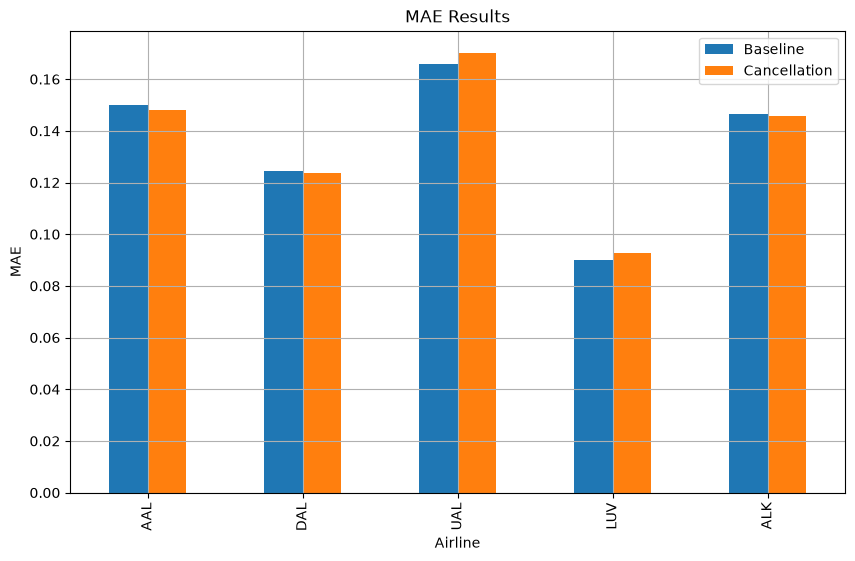

In [54]:
plot8 = mae_results.plot(kind="bar",figsize=(10, 6))

plot8.set_title("MAE Results")
plot8.set_xlabel("Airline")
plot8.set_ylabel("MAE")
plot8.grid()


plt.savefig(figure_directory / "mae_by_airline.png",bbox_inches="tight")

plt.show()

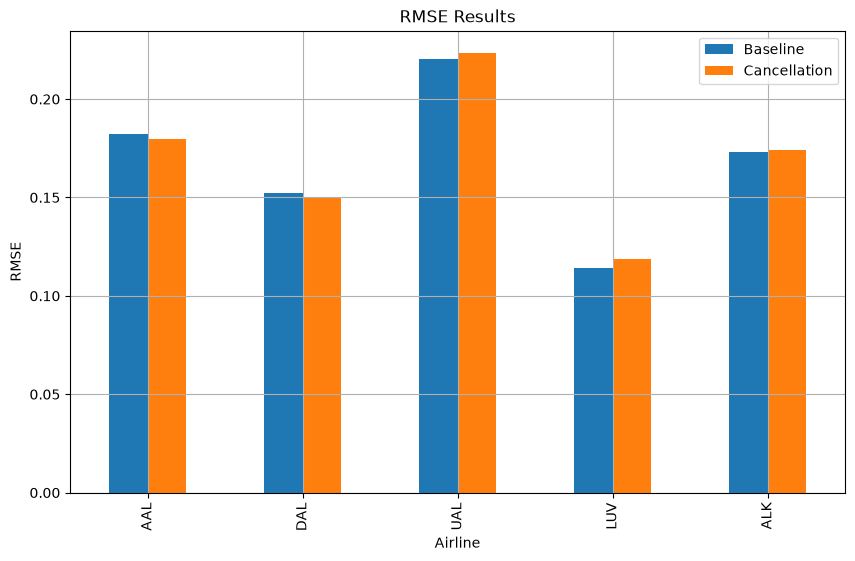

In [55]:
plot9 = rmse_results.plot(kind="bar",figsize=(10, 6))


plot9.set_title("RMSE Results")
plot9.set_xlabel("Airline")
plot9.set_ylabel("RMSE")
plot9.grid()


plt.savefig(figure_directory / "rmse_by_airline.png",bbox_inches="tight")

plt.show()

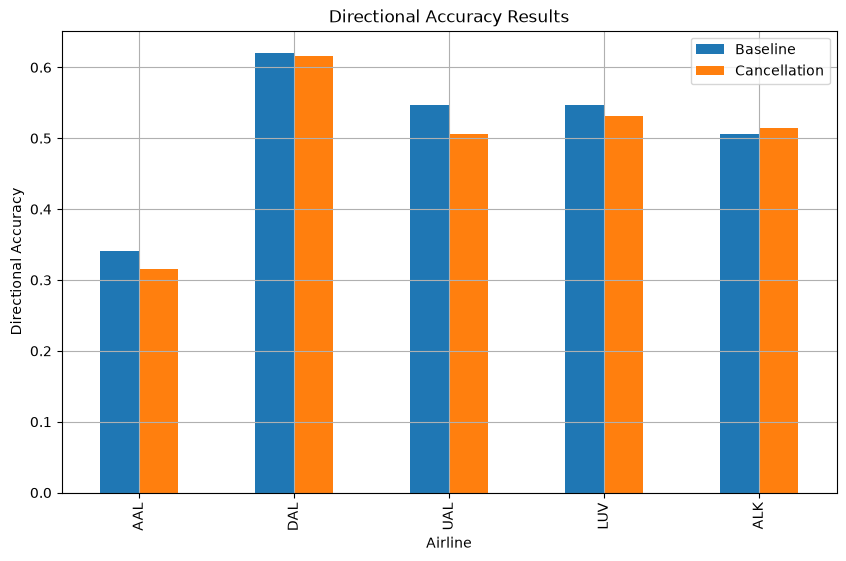

In [56]:
plot10 = (accuracy_results).plot(kind="bar",figsize=(10, 6))

plot10.set_title("Directional Accuracy Results")
plot10.set_xlabel("Airline")
plot10.set_ylabel("Directional Accuracy")
plot10.grid()

plt.savefig(figure_directory / "directional_accuracy_by_airline.png",bbox_inches="tight")

plt.show()

#### Interpretation 
The baseline model generally performs slightly better than the cancellation model, which means adding cancellation rates does not improve the 30 day return forecasting across the airlines.

For MAE, the cancellation model is slightly better for AAL, DAL, and ALK, but worse for UAL and LUV. The differences are small in every case. LUV has the lowest forecast error overall, with a baseline MAE of 0.0900, while UAL has the highest errors at around 0.17.

For RMSE, the cancellation model improves AAL and DAL slightly, but performs worse for UAL, LUV, and ALK. The differences are very small, showing that cancellations are not adding much predictive value.

For directional accuracy, the baseline model performs better for AAL, DAL, UAL, and LUV. ALK is the only airline where the cancellation model improves directional accuracy, rising slightly from 50.64% to 51.48%. DAL has the strongest directional accuracy overall at about 62%, while AAL performs poorly at only about 34% for the baseline model and 32% with cancellations.

# Final Conclusion

This project looked at whether airline cancellations could help predict equity returns over the next 30 trading days. Using historical airline returns, rolling volatility, downside volatility, CAPM beta, and Fama-French factors, I built a baseline forecasting model to predict future stock returns. I then compared this model with a second model that also included monthly airline cancellation rates. Overall, the results show that adding cancellation data does not consistently improve forecasting performance. For AAL, the cancellation model slightly reduced MAE from 14.98% to 14.81% and RMSE from 18.20% to 17.96%, but directional accuracy fell from 34.11% to 31.57%. Cancellation data also produced small improvements in some error measures for DAL and ALK, while performance worsened for UAL and LUV. DAL had the strongest directional accuracy at 62.08% in the baseline model, while LUV had the lowest forecast errors, with a baseline MAE of 9.00% and RMSE of 11.42%. Overall, these results show that although cancellations are a relevant measure of airline operational success, they do not help predict 30 day airline stock returns beyond the market and risk factors already included in the baseline model.